In [ ]:
from	google.colab	import	drive
drive.mount('/content/drive')
import	os
PROJECT_PATH	=	'/content/drive/MyDrive/DAPortfolio/churn_revenue_risk'
os.makedirs(PROJECT_PATH,	exist_ok=True)
os.chdir(PROJECT_PATH)
print("Working	directory:",	os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working	directory: /content/drive/MyDrive/DAPortfolio/churn_revenue_risk


In [ ]:
!pip	install	-q	--upgrade	xgboost	shap

In [ ]:
import	pandas,	numpy,	sklearn
print("pandas:",	pandas.__version__)
print("numpy:",	numpy.__version__)
print("scikit-learn:",	sklearn.__version__)

pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1


In [ ]:
import	numpy	as	np
import	pandas	as	pd
import	matplotlib.pyplot	as	plt
import	seaborn	as	sns
from	sklearn.model_selection	import	train_test_split
from	sklearn.preprocessing	import	StandardScaler,	LabelEncoder
from	sklearn.linear_model	import	LogisticRegression
from	sklearn.ensemble	import	RandomForestClassifier
from	sklearn.metrics	import	(classification_report,	confusion_matrix,
roc_auc_score,	roc_curve,	precision_recall_curve)
import	xgboost	as	xgb
import	shap
sns.set_theme(style="whitegrid")
np.random.seed(42)

In [ ]:
from	google.colab	import	userdata
import	os
#	kagglehub	looks	for	this	exact	env	var	name	—	read	your	secret	into	it
os.environ['KAGGLE_API_TOKEN']	=	userdata.get('dataanalyticsprojects')
!pip	install	-q	kagglehub
import	kagglehub
dataset_path	=	kagglehub.dataset_download('blastchar/telco-customer-churn')
print("Dataset	downloaded	to:",	dataset_path)
import	os	as	_os
print(_os.listdir(dataset_path))

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset	downloaded	to: /kaggle/input/telco-customer-churn
['WA_Fn-UseC_-Telco-Customer-Churn.csv']


**Load	and	reframed	to ZAR Rand	values**

The	raw	dataset	uses	USD-scale	monthly	charges.	Rescale	to	realistic	SA	mobile/fibre	ARPU	(Average
Revenue	Per	User)	bands	so	the	business	framing	is	authentic	—	SA	postpaid	mobile	ARPU	typically	sits
in	the	R250–R900/month	range

In [ ]:
import	os
#	dataset_path	came	from	kagglehub.dataset_download()	above
csv_filename	=	[f	for	f	in	os.listdir(dataset_path)	if	f.endswith('.csv')][0]
df	=	pd.read_csv(os.path.join(dataset_path,	csv_filename))
#	Rescale	MonthlyCharges	(originally	~$18-$120)	to	SA	ARPU	(~R250-R900)
old_min,	old_max	=	df['MonthlyCharges'].min(),	df['MonthlyCharges'].max()
df['MonthlyCharges_ZAR']	=	250	+	(df['MonthlyCharges']	-	old_min)	/	(old_max	-	old_min)	*	650
df['MonthlyCharges_ZAR']	=	df['MonthlyCharges_ZAR'].round(2)
#	TotalCharges	has	some	blank	strings	in	the	raw	file	—	clean	it
df['TotalCharges']	=	pd.to_numeric(df['TotalCharges'],	errors='coerce')
df['TotalCharges_ZAR']	=	df['MonthlyCharges_ZAR']	*	(df['TotalCharges']	/
df['MonthlyCharges']).fillna(df['tenure'])
df	=	df.dropna(subset=['TotalCharges_ZAR'])
df[['MonthlyCharges',	'MonthlyCharges_ZAR',	'tenure',	'Churn']].head()

,MonthlyCharges,MonthlyCharges_ZAR,tenure,Churn
0,29.85,325.02,1,No
1,56.95,500.30,34,No
2,53.85,480.25,2,Yes
3,42.30,405.55,45,No
4,70.70,589.23,2,Yes


**Notebook	Narrative	Structure**




**Implementation**





*   Exploratory	Data	Analysis



Overall	churn	rate:	26.5%


/tmp/ipykernel_3441/2056319592.py:10: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3441/2056319592.py:11: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig('eda_churn_overview.png',	dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


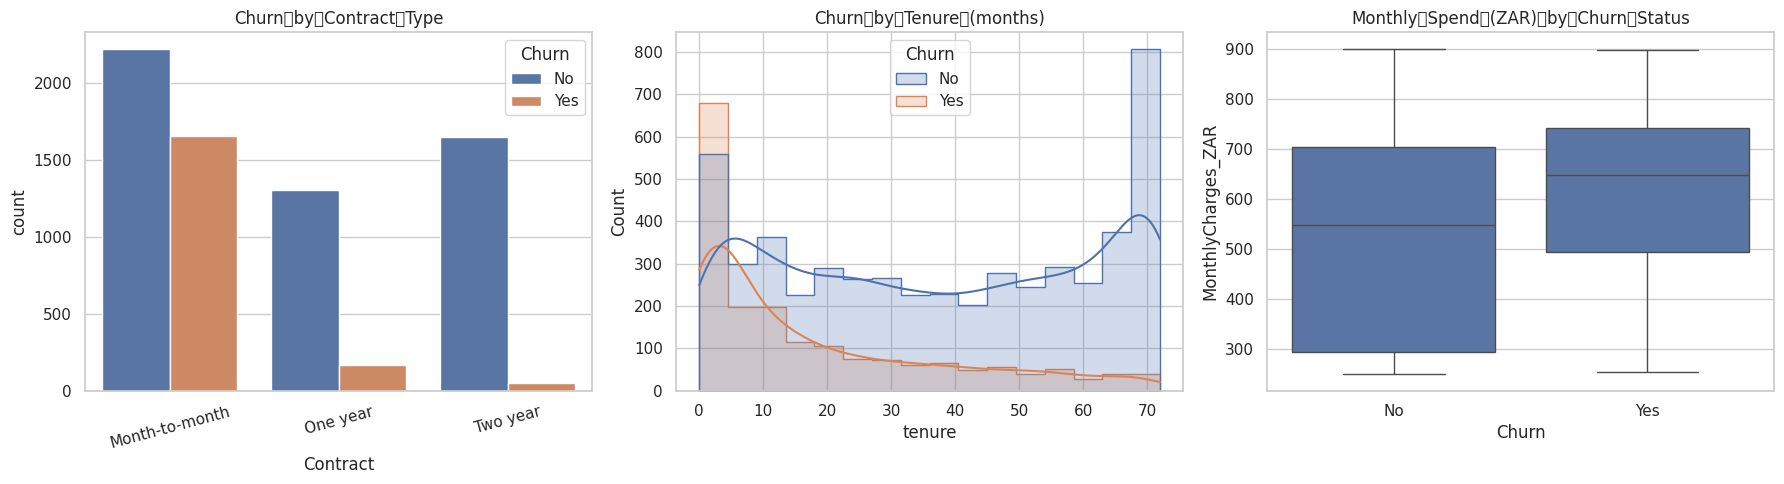

In [ ]:
print(f"Overall	churn	rate:	{(df['Churn']=='Yes').mean():.1%}")
fig,	axes	=	plt.subplots(1,	3,	figsize=(18,	5))
sns.countplot(data=df,	x='Contract',	hue='Churn',	ax=axes[0])
axes[0].set_title('Churn	by	Contract	Type')
axes[0].tick_params(axis='x',	rotation=15)
sns.histplot(data=df,	x='tenure',	hue='Churn',	kde=True,	element='step',	ax=axes[1])
axes[1].set_title('Churn	by	Tenure	(months)')
sns.boxplot(data=df,	x='Churn',	y='MonthlyCharges_ZAR',	ax=axes[2])
axes[2].set_title('Monthly	Spend	(ZAR)	by	Churn	Status')
plt.tight_layout()
plt.savefig('eda_churn_overview.png',	dpi=150)
plt.show()

Month-to-month	contract	customers	churn	at	a	dramatically	higher	rate
than	1-2	year	contracts, this	alone	suggests	a	retention	lever	(contract	incentives)	before	we	even build	a	model.	Churn	is	also	concentrated	in	the	first	~10	months,	which	matches	the	RICA-porting
pattern	of	early-tenure	switching	seen	in	SA	telecom	coverage



*   Feature	engineering	and	encoding



In [ ]:
df_model	=	df.drop(columns=['customerID',	'MonthlyCharges',	'TotalCharges'])
df_model['Churn']	=	(df_model['Churn']	==	'Yes').astype(int)
categorical_cols	=	df_model.select_dtypes(include='object').columns.tolist()
df_encoded	=	pd.get_dummies(df_model,	columns=categorical_cols,	drop_first=True)
X	=	df_encoded.drop(columns=['Churn'])
y	=	df_encoded['Churn']
X_train,	X_test,	y_train,	y_test	=	train_test_split(
X,	y,	test_size=0.2,	stratify=y,	random_state=42
)
print(f"Train	churn	rate:	{y_train.mean():.1%}	|	Test	churn	rate:	{y_test.mean():.1%}")

Train	churn	rate:	26.5%	|	Test	churn	rate:	26.5%




*   Baseline	model:	Logistic	Regression



In [ ]:
scaler	=	StandardScaler()
X_train_scaled	=	scaler.fit_transform(X_train)
X_test_scaled	=	scaler.transform(X_test)
log_reg	=	LogisticRegression(max_iter=1000,	class_weight='balanced',	random_state=42)
log_reg.fit(X_train_scaled,	y_train)
y_pred_lr	=	log_reg.predict(X_test_scaled)
y_proba_lr	=	log_reg.predict_proba(X_test_scaled)[:,	1]
print("Logistic	Regression:")
print(classification_report(y_test,	y_pred_lr))
print(f"ROC-AUC:	{roc_auc_score(y_test,	y_proba_lr):.3f}")

Logistic	Regression:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC:	0.841




*   XGBoost



In [ ]:
scale_pos_weight	=	(y_train	==	0).sum()	/	(y_train	==	1).sum()
xgb_model	=	xgb.XGBClassifier(
n_estimators=200,	max_depth=4,	learning_rate=0.05,
scale_pos_weight=scale_pos_weight,	eval_metric='logloss',	random_state=42
)
xgb_model.fit(X_train,	y_train)
y_pred_xgb	=	xgb_model.predict(X_test)
y_proba_xgb	=	xgb_model.predict_proba(X_test)[:,	1]
print("XGBoost:")
print(classification_report(y_test,	y_pred_xgb))
print(f"ROC-AUC:	{roc_auc_score(y_test,	y_proba_xgb):.3f}")

XGBoost:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC:	0.840


**Logistic regression vs XGBoost**

Logistic regression and XGBoost produced nearly identical performance (ROC-AUC 0.841 vs 0.840), suggesting the churn signal in this dataset is largely linear and well-captured by a handful of strong features (contract type, tenure). Given comparable performance, XGBoost was retained for the remainder of the analysis primarily for its SHAP-based explainability and its use in the revenue-at-risk ranking, not because it meaningfully outperforms the simpler baseline.



*   Precision-recall



/tmp/ipykernel_3441/4109827010.py:9: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig('precision_recall_tradeoff.png',	dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


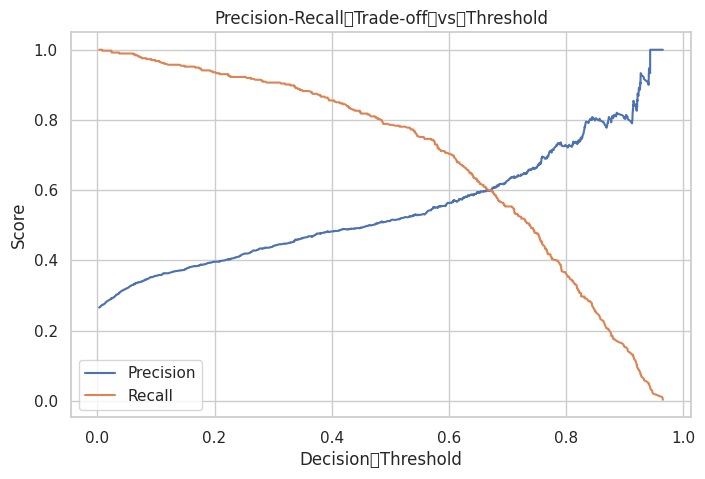

In [ ]:
precisions,	recalls,	thresholds	=	precision_recall_curve(y_test,	y_proba_xgb)
fig,	ax	=	plt.subplots(figsize=(8,	5))
ax.plot(thresholds,	precisions[:-1],	label='Precision')
ax.plot(thresholds,	recalls[:-1],	label='Recall')
ax.set_xlabel('Decision	Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision-Recall	Trade-off	vs	Threshold')
ax.legend()
plt.savefig('precision_recall_tradeoff.png',	dpi=150)
plt.show()

Precision (Blue Line): This measures the reliability of the churn predictions. As the decision thresholds increases, precision goes up. Meaning At high thresholds,when the model says a customer will churn, it is almost always right


Recall (Orange Line): This measures how many actual churners the model is actually catching. As the threshold increases, recall drops. Hence A high threshold means the model misses a lot of customers who are actually about to leave.



*   Confusion	matrix	at	chosen	threshold


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_3441/3811425771.py:10: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix.png',	dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


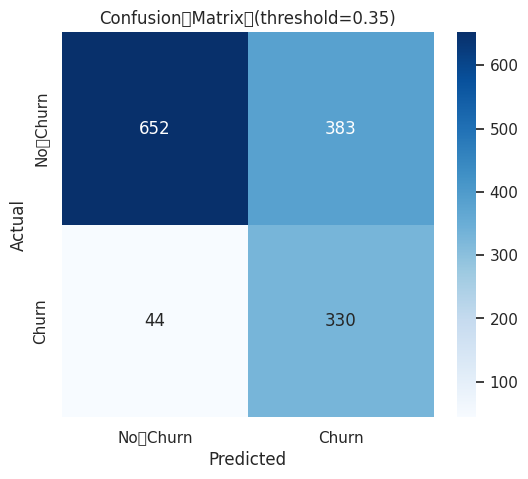

In [ ]:
threshold	=	0.35		#	chosen	to	favor	recall,	justified	by	reasoning	above
y_pred_adjusted	=	(y_proba_xgb	>=	threshold).astype(int)
cm	=	confusion_matrix(y_test,	y_pred_adjusted)
fig,	ax	=	plt.subplots(figsize=(6,	5))
sns.heatmap(cm,	annot=True,	fmt='d',	cmap='Blues',
xticklabels=['No	Churn',	'Churn'],	yticklabels=['No	Churn',	'Churn'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion	Matrix	(threshold={threshold})')
plt.savefig('confusion_matrix.png',	dpi=150)
plt.show()

At a threshold of 0.35, the model correctly identifies 330 of 374 actual churners (88% recall), at the cost of also flagging 383 customers who did not actually churn (46% precision). Compared to the default 0.5 threshold, lowering it clearly trades precision for recall, we're deliberately over-flagging to avoid missing real churners, since a missed high-value churner costs more than a wasted retention call.



*   Revenue-at-Risk	ranking



Top	15	customers	retention	should	call	first:
Top	15	customers	retention	should	call	first:


/tmp/ipykernel_3441/2087950238.py:23: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig('revenue_at_risk_scatter.png',	dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


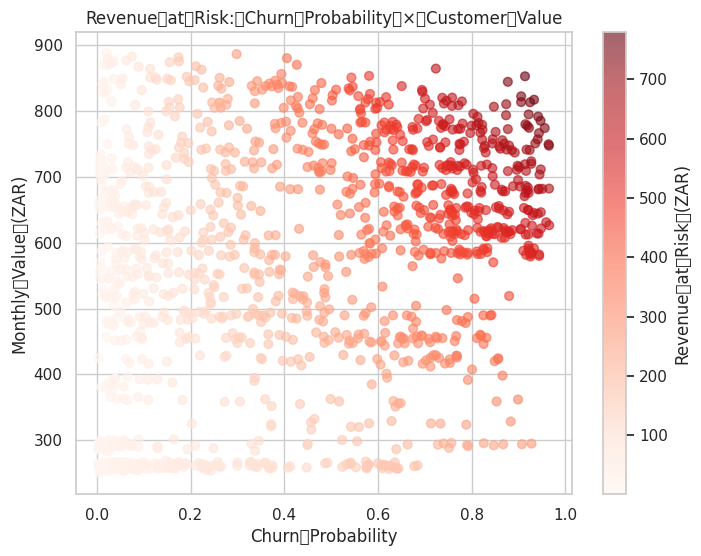

Total	monthly	revenue	at	risk	in	top	50	priority	calls:	R34,244.31


In [ ]:
results	=	X_test.copy()
results['actual_churn']	=	y_test.values
results['churn_probability']	=	y_proba_xgb
results['monthly_value_zar']	=	df.loc[X_test.index,	'MonthlyCharges_ZAR'].values
results['revenue_at_risk_zar']	=	results['churn_probability']	*	results['monthly_value_zar']
print("Top	15	customers	retention	should	call	first:")

retention_priority_list	=	results.sort_values('revenue_at_risk_zar',	ascending=False)
retention_priority_list	=	retention_priority_list[
['churn_probability',	'monthly_value_zar',	'revenue_at_risk_zar',	'actual_churn']
]

print("Top	15	customers	retention	should	call	first:")
retention_priority_list.head(15)

fig,	ax	=	plt.subplots(figsize=(8,	6))
scatter	=	ax.scatter(results['churn_probability'],	results['monthly_value_zar'],
c=results['revenue_at_risk_zar'],	cmap='Reds',	alpha=0.6,	s=40)
ax.set_xlabel('Churn	Probability')
ax.set_ylabel('Monthly	Value	(ZAR)')
ax.set_title('Revenue	at	Risk:	Churn	Probability	×	Customer	Value')
plt.colorbar(scatter,	label='Revenue	at	Risk	(ZAR)')
plt.savefig('revenue_at_risk_scatter.png',	dpi=150)
plt.show()

total_revenue_at_risk	=	retention_priority_list.head(50)['revenue_at_risk_zar'].sum()
print(f"Total	monthly	revenue	at	risk	in	top	50	priority	calls:	R{total_revenue_at_risk:,.2f}")

Plotting churn probability against monthly customer value surfaces a distinct cluster in the upper-right, customers with both a high probability of churning and a high monthly spend (R600-800).

These are the customers we would place at the top of a retention call list, since losing them represents the largest combined probability-weighted revenue loss.

In contrast, customers in the upper-left (high value, low churn probability) don't need proactive intervention right now, and customers in the lower-right (high churn probability, low value) are lower priority despite the high risk score, since the revenue impact of losing them is comparatively small.

/tmp/ipykernel_3441/3048808794.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,	X_test,	show=False)


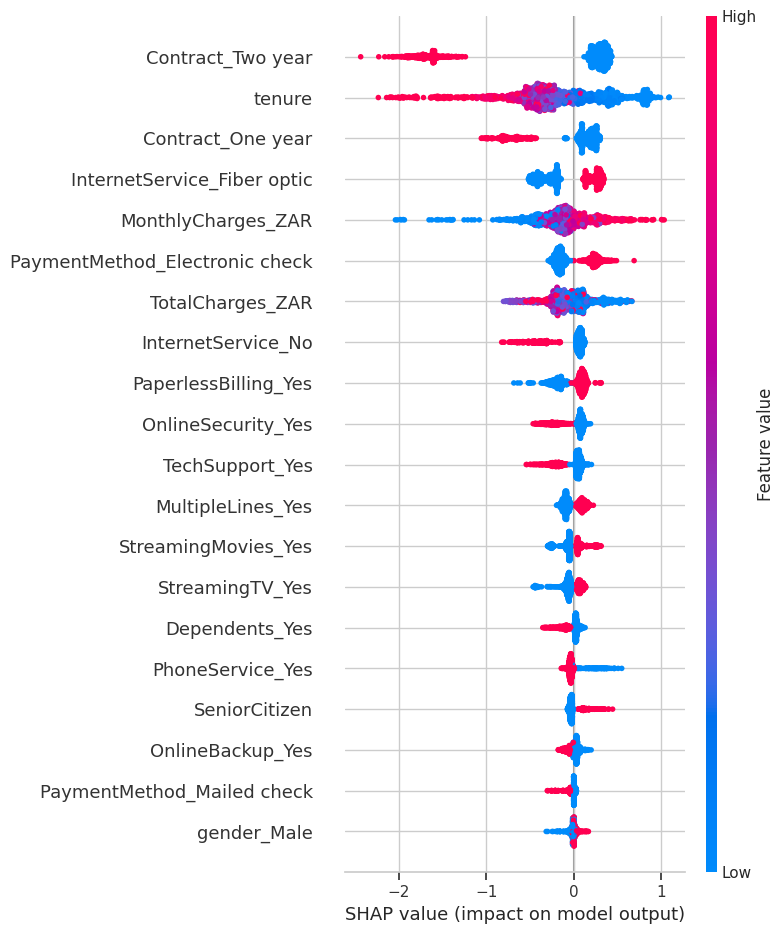

In [ ]:
explainer	=	shap.TreeExplainer(xgb_model)
shap_values	=	explainer.shap_values(X_test)
shap.summary_plot(shap_values,	X_test,	show=False)
plt.tight_layout()
ax.annotate(
    'Priority retention targets\n(high churn risk + high value)',
    xy=(0.75, 780), xytext=(0.35, 850),
    fontsize=10, fontweight='bold', color='#8B0000',
    arrowprops=dict(arrowstyle='->', color='#8B0000', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', fc='#FFF0F0', ec='#8B0000', alpha=0.9)
)
plt.savefig('shap_summary.png',	dpi=150,	bbox_inches='tight')
plt.show()

Ranking features by mean SHAP value shows **contract type**, **tenure**, and **monthly** charges as the three biggest drivers of the model's predictions.



*  Customers on two-year contracts push the prediction firmly toward "no churn" (the blue cluster sits left of zero), while month-to-month-equivalent short contracts push toward churn.

*   Tenure shows a similar pattern, low-tenure customers (blue, low feature value) push right toward churn, high-tenure customers push left away from it.



*   Tenure shows a similar pattern, low-tenure customers (blue, low feature value) push right toward churn, high-tenure customers push left away from it.
*   Fiber optic internet service and electronic check as a payment method both push toward churn when present (pink dots sit right of zero), while the remaining features further down the list contribute comparatively little to the model's output.



*   This tells us the model isn't spreading its decision-making thinly across dozens of weak signals, a small number of features are doing most of the work, which is also consistent with why logistic regression performed nearly as well as XGBoost.













**Business Recommandation**

At a threshold of 0.35, the model catches 88% of actual churners (330 of 374), at the cost of 383 false positives. That's a deliberate trade-off. A missed high-value churner costs the business more than a wasted retention call to someone who wasn't actually leaving.

Ranking customers by revenue-at-risk (churn probability times monthly value) instead of churn probability alone surfaces a clear priority segment: high churn probability combined with monthly spend in the R600 to R800 range. This is who retention should call first. The top 50 customers by this score represent R34,244.31 in monthly recurring revenue at risk. Customers with high value but low churn risk don't need action right now. Customers with high churn risk but low value are lower priority despite the risk score, since losing them barely moves the needle on revenue.

SHAP shows the model's predictions come down to three factors mostly: contract type, tenure, and monthly charges. Fiber optic internet and electronic check payment show up as secondary but consistent effects. Shorter contracts, low tenure, and electronic check push toward a churn prediction. Two-year contracts and long tenure push firmly the other way.

This concentration in a handful of features, rather than the prediction being spread thin across dozens of weak signals, also explains why logistic regression performed almost as well as XGBoost (ROC-AUC 0.841 vs 0.840). The churn signal in this data is mostly linear, and a simple model already captures most of it.

Practically, this points to a lever earlier in the process than the retention call list itself. Contract type and tenure being the two biggest drivers suggests offering a contract-renewal incentive to month-to-month customers as they approach the tenure point where churn risk historically climbs, before they ever show up on this list.